# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

<font color="MidnightBlue">The goal of this analisys is to find which features of the dataset have the greatest impact on the price of a used car.</font>

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

<font color="MidnightBlue">I want to see the first 5 rows to have an idea what kind of columns the dataset has and run .info() to see the datatypes. As we can see, there are typical car features like paint color, fuel and cylinderd etc. And the df contains primerly string data type</font>

In [404]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.feature_selection import SequentialFeatureSelector



df = pd.read_csv("./data/vehicles.csv")
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [405]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

<font color="MidnightBlue"> Now I want to explore the missing data. </font>

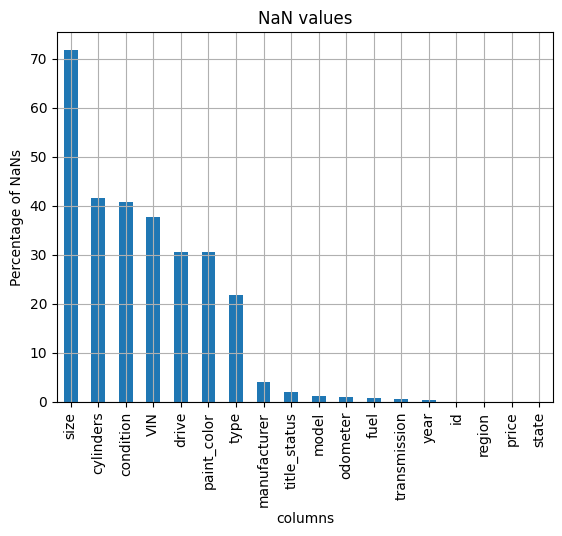

In [406]:
nan_counts = df.isna().sum().sort_values(ascending=False)
nan_counts = (nan_counts / df.shape[0]) * 100
nan_counts.plot(kind='bar')
plt.title("NaN values")
plt.ylabel("Percentage of NaNs")
plt.xlabel("columns")
plt.grid(True)
plt.show()


<font color="MidnightBlue"> 70% of the "size" column are missing and almost a half of the information about cylinders and condition are missing, and more then a third information for VIN.
I want to explore the missing data and see what I can do about it. First, I want to check how size column looks like. Briefly looking at the notnull sizes, I saw that this data is categorical, so maybe I can find the momdel or make information and fillup the missing size information for the similar models/makes.
</font>

In [407]:
df[~df["size"].isna()][["manufacturer", "model", "size"]]

,manufacturer,model,size
31,ford,f-150 xlt,full-size
46,jeep,compass,full-size
55,ford,f250 super duty,full-size
59,honda,odyssey,full-size
65,ford,f450,full-size
...,...,...,...
426809,jeep,gand wagoneer,full-size
426831,nissan,300zx coupe with t-tops,sub-compact
426833,jaguar,xk8 convertible,compact
426836,ram,2500,full-size


<font color="MidnightBlue"> However, this result shows that some model names can have different sizes. I am so bad with cars, I know nothing about them. so maybe the type will help.  </font>

In [408]:
pd.crosstab(df["model"], df["size"])
df.groupby("model")["size"].nunique().sort_values(ascending=False)

model
explorer                       4
fit                            4
fusion se                      4
wrx                            4
challenger                     4
                              ..
e350 14 passenger van          0
e350 12' box van               0
e350 12' box truck             0
e320 4matic                    0
🔥GMC Sierra 1500 SLE🔥 4X4 🔥    0
Name: size, Length: 29649, dtype: int64

In [409]:
df[(df["model"].isin(["explorer", "fit", "fusion se", "wrx", "challenger"])) & (~df["size"].isna())][["model", "manufacturer", "size", "type", "year"]]

,model,manufacturer,size,type,year
2090,fusion se,ford,full-size,sedan,2013.0
2196,explorer,ford,mid-size,SUV,2013.0
2222,explorer,ford,mid-size,SUV,2016.0
3835,explorer,ford,full-size,SUV,2018.0
3934,explorer,ford,full-size,SUV,2016.0
...,...,...,...,...,...
424172,fusion se,ford,mid-size,sedan,2010.0
424918,explorer,ford,full-size,pickup,2015.0
425133,fusion se,ford,mid-size,sedan,2012.0
425444,explorer,ford,full-size,SUV,2013.0


<font color = "MidnightBlue">Nope, type hasn't help. They can be SUVs with different sizes. </font>

In [410]:
df.groupby(["manufacturer", "model", "year", "type"])["size"].nunique().sort_values(ascending=False)


manufacturer  model                       year    type       
ford          mustang                     2012.0  coupe          4
              fiesta                      2011.0  sedan          4
              mustang                     1996.0  coupe          4
                                          2004.0  convertible    4
                                          2006.0  coupe          4
                                                                ..
gmc           sierra duramax 2500 hd 4x4  2017.0  truck          0
                                          2020.0  truck          0
              sierra duramax 2500 hd all  2015.0  truck          0
              sierra duramax 2500 hd at4  2020.0  truck          0
volvo         xc90t6 awd 24733 miles      2018.0  SUV            0
Name: size, Length: 59215, dtype: int64

In [411]:
df[(df["model"] == "mustang") & (df["year"] == 2011.0) & (df["type"] == "coupe") & (df["size"].notna())][["size", "title_status", "manufacturer", "cylinders"]]

,size,title_status,manufacturer,cylinders
107166,mid-size,clean,ford,6 cylinders
242844,compact,clean,ford,8 cylinders
347814,full-size,clean,ford,6 cylinders
366024,sub-compact,clean,ford,8 cylinders


<font color = "Midnightblue"> So my hypothesis did not work out, it is possible to have different sizes for the cars even if they have the same model name, year and type. But I cannot get rid of the 70% percent of data. Maybe I will replace the size with the most common for a particluar model and year. I am moving to cylinders exploration </font>

In [412]:
df.groupby(["manufacturer", "model", "year", "fuel", "type"])["cylinders"].nunique().sort_values(ascending=False)

manufacturer   model                   year    fuel   type 
honda          accord                  2004.0  gas    coupe    4
bmw            5 series                2014.0  gas    sedan    4
honda          civic                   2010.0  gas    sedan    4
jeep           cherokee                2016.0  gas    SUV      4
ford           escape                  2020.0  gas    SUV      4
                                                              ..
chrysler       pt crusier              2007.0  gas    wagon    0
mercedes-benz  e-class e 300           2018.0  other  sedan    0
                                               gas    sedan    0
                                       2017.0  gas    sedan    0
volvo          xc90t6 awd 24733 miles  2018.0  gas    SUV      0
Name: cylinders, Length: 63075, dtype: int64

In [413]:
df[(df["model"] == "accord") & (df["year"] == 2004.0) & (df["type"] == "coupe") & (df["cylinders"].notna()) & (df["fuel"] == "gas")][["cylinders", "size"]]

,cylinders,size
104038,6 cylinders,NaN
123382,4 cylinders,compact
178089,6 cylinders,mid-size
179636,4 cylinders,compact
196796,3 cylinders,compact
230812,4 cylinders,NaN
234549,4 cylinders,NaN
257566,6 cylinders,mid-size
275446,6 cylinders,NaN
347486,4 cylinders,NaN


<font color="MidnightBlue">The field above is the demonstration that the same model, year and type can have different number of cylinders. Maybe I can research how the cylinders are related to the size and pick the most common for each missing value. </font>

In [414]:
pd.crosstab(df["size"], df["cylinders"])

cylinders,10 cylinders,12 cylinders,3 cylinders,4 cylinders,5 cylinders,6 cylinders,8 cylinders,other
size,,,,,,,,
compact,199,6,151,11080,207,2616,1214,228
full-size,679,57,60,8018,296,20089,27230,221
mid-size,39,21,41,16035,361,13553,3467,77
sub-compact,12,4,43,1436,28,438,225,32


<font color = "MidnightBluew">Moving to condition exploration.</font>

In [415]:
df["condition"].value_counts().sort_values(ascending=False)

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

<font color="MidnightBlue">Here we see that most of the cars are in "good" and "excellent" condition, and further the worse the condition is, the lower is the count for such cars. We have a big chunk of data with missing condition values, so I am going to explore its relationship with odometer, title_status (I had to research the meaning of this feature) In the data preparation phase I will dive deeper into the relationship berween these three features, since some data type transformation has to be done.</font>

In [416]:
df[df["condition"].notna()][["year", "odometer", "condition"]]


,year,odometer,condition
27,2014.0,57923.0,good
28,2010.0,71229.0,good
29,2020.0,19160.0,good
30,2017.0,41124.0,good
31,2013.0,128000.0,excellent
...,...,...,...
426875,2019.0,32226.0,good
426876,2020.0,12029.0,good
426877,2020.0,4174.0,good
426878,2018.0,30112.0,good


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [417]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [418]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

<font color="MidnightBlue">I want to explor the datatype and content of each column to decide how to transfrom them. I'll start from region, I want to see how many of them there.</font>

In [419]:
df["region"].value_counts().count()

np.int64(404)

<font color="MidnightBlue">404 unique regions. This number is too high, and I think does not really affect the price of the car, so probably I will remove this column.  </font>

<font color="MidnightBlue">First I want to make all the string entries lower case</font>

In [420]:
df_clean = df.copy()
df_clean = df_clean.drop(columns="region")
df_clean["year"].isna().value_counts()

year
False    425675
True       1205
Name: count, dtype: int64

In [421]:
df_clean = df_clean.apply(lambda col: col.str.lower() if (col.dtype == "object") | (col.dtype == "str") else col)
df_clean["type"]

0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
            ...    
426875        sedan
426876        sedan
426877    hatchback
426878        sedan
426879        coupe
Name: type, Length: 426880, dtype: str

<font color="MidnightBlue">Luckily, all price values are in place and correct data type, we can leave it as it is. We have a little bit of missing "year" values, so these rows can be deleted.</font>

In [422]:
df_clean = df_clean.dropna(subset=["year"])
df["manufacturer"].isna().value_counts()

manufacturer
False    409234
True      17646
Name: count, dtype: int64

<font color="MidnightBlue"> I will try the missing manufacturer infering the value from the model, but first I want to make sure that the values are uniue for each manifacturer.</font>

In [423]:
#the table of all pair manufacturer-model where values exist
man_model = df_clean[["manufacturer", "model", "type"]].drop_duplicates().dropna().sort_values(["manufacturer", "model", "type"])
man_model.groupby("model")["manufacturer"].nunique().sort_values(ascending=False)



model
truck                     10
convertible                9
van                        9
coupe                      8
pickup                     8
                          ..
edge sel awd               1
edge sel automatic         1
edge sel 4dr crossover     1
edge sel 2.7l              1
♿ vmi                      1
Name: manufacturer, Length: 20673, dtype: int64

<font color="MidnightBlue">I noticed that type and model in some places are the same, so maybe we can refill the data from the type as well. And the values are inconsistent with truck and pickups the same model can have a different type. Apparently, all pickups are trucks, I am going to rename all pickups as trucks. </font>

In [424]:
man_model[man_model["manufacturer"] == "chevrolet"]["model"].value_counts()


model
hhr                        9
traverse                   8
corvette                   7
express                    7
silverado                  7
                          ..
z28                        1
z28 camaro                 1
z28 camaro converitible    1
z28 convertible            1
zl1 camaro                 1
Name: count, Length: 2192, dtype: int64

In [425]:
df_clean["type"].value_counts().count()

np.int64(13)

In [426]:
df_clean["type"].value_counts()

type
sedan          86860
suv            76981
pickup         43128
truck          35279
other          22110
coupe          19181
hatchback      16588
wagon          10751
van             8457
convertible     7722
mini-van        4825
offroad          609
bus              517
Name: count, dtype: int64

<font color="MidnightBlue">There are too many unique models for a single manufacturer, so I will remove this column. But first I want to fill the missing values in type from the model column of they're == truck or pickup
</font>

In [427]:
types = df_clean["type"].unique().dropna()

mask = (
    df_clean["type"].isna() &
    df_clean["model"].isin(types)
)
df_clean.loc[mask, "type"] = df_clean.loc[mask, "model"]


<font color="MidnightBlue">Next I want to try to search for the models with types and if the same model has a NaN in the type, I will refill it with the same type.</font>

In [428]:
models_with_types = df_clean[(df_clean["model"].notna()) & (df_clean["type"].notna())][["model", "type"]]


model_to_type = (
    models_with_types
    .drop_duplicates("model")
    .set_index("model")["type"]
)
df_clean["type"] = df_clean["type"].fillna(
    df_clean["model"].map(model_to_type)
)
df_clean["type"].isna().sum() / df_clean.shape[0] * 100
model_to_type

model
sierra 1500 crew cab slt    pickup
silverado 1500              pickup
silverado 1500 crew         pickup
tundra double cab sr        pickup
f-150 xlt                    truck
                             ...  
cj 3a willys                 other
rx& gls sport                coupe
gand wagoneer                  suv
96 suburban                    suv
paige glenbrook touring      other
Name: type, Length: 23769, dtype: str

<font color="MidnightBlue"> the percentage of the missing values in column "type" has reduced to 3% Below is a little bit more of fillin up the types column. And I will fill the missing manufacturer column. </font>

In [429]:
df_clean[df_clean["type"].isna()][["model", "type", "manufacturer"]]
f = (
    df_clean["model"]
    .str.split()
    .str[2]
)
for i in range(1, 5):
    df_clean[f"model_{i}"] = (
    df_clean["model"]
    .str.split()
    .str[i]
)

for i in range(1, 5):
    mask = df_clean["type"].isna() & df_clean[f"model_{i}"].isin(types)
    df_clean.loc[mask, "type"] = df_clean.loc[mask, f"model_{i}"]

print(f"{df_clean["type"].isna().sum() / df_clean.shape[0] * 100}% of missimng types")
print(f"{df_clean["manufacturer"].isna().sum() / df_clean.shape[0] * 100}% of missimng manufacturers after filling")


2.492042050860398% of missimng types
3.8637458154695485% of missimng manufacturers after filling


<font color="MidnightBlue">No matching manufacturer names in the enngineered model columns.</font>

In [430]:
manufacturers = df_clean["manufacturer"].dropna().unique()
for i in range(1, 5):
    print(f"Matuching manufacturer names in model_{i} {df_clean[f"model_{i}"].isin(manufacturers).sum()}")

Matuching manufacturer names in model_1 0
Matuching manufacturer names in model_2 0
Matuching manufacturer names in model_3 0
Matuching manufacturer names in model_4 0


<font color="MidnightBlue">Before deleting the model/models column I want to see if we can extract information about cylinders from them. After my research, I figured, the Vand the number means the number of cylinders.</font>

In [431]:
print(f"cyl missing before filling up {df_clean["cylinders"].isna().sum() / df_clean.shape[0] * 100}")
no_cylinder = df_clean[df_clean["cylinders"].isna()]
for i in range(1, 5):
  mask = (df_clean["cylinders"].isna() &
          df_clean[f"model_{i}"].str.contains(r"\bv\d+\b")
          )
  df_clean.loc[mask, "cylinders"] = df_clean.loc[mask, f"model_{i}"]

print(f"cyl missing after filling up {df_clean["cylinders"].isna().sum() / df_clean.shape[0] * 100}")



cyl missing before filling up 41.71985669818524
cyl missing after filling up 41.67193281259177


<font color="MidnightBlue">It hasn't significantly reduced the number of missing values, I will try to convert the datat type and cleanup the columns to make an analysis for filling up more data </font>

In [432]:
df_clean["cylinders"] = (
    df_clean["cylinders"]
    .str.replace(" cylinders", "", regex=False)
)
extracted = (df_clean["cylinders"].str.extract(r"\b(v\d+)\b", expand=False))
df_clean["cylinders"] = extracted.fillna(df_clean["cylinders"])
df_clean["cylinders"] = df_clean["cylinders"].str.replace("v", "", regex=False)
df_clean = df_clean[df_clean["cylinders"] != "other"]



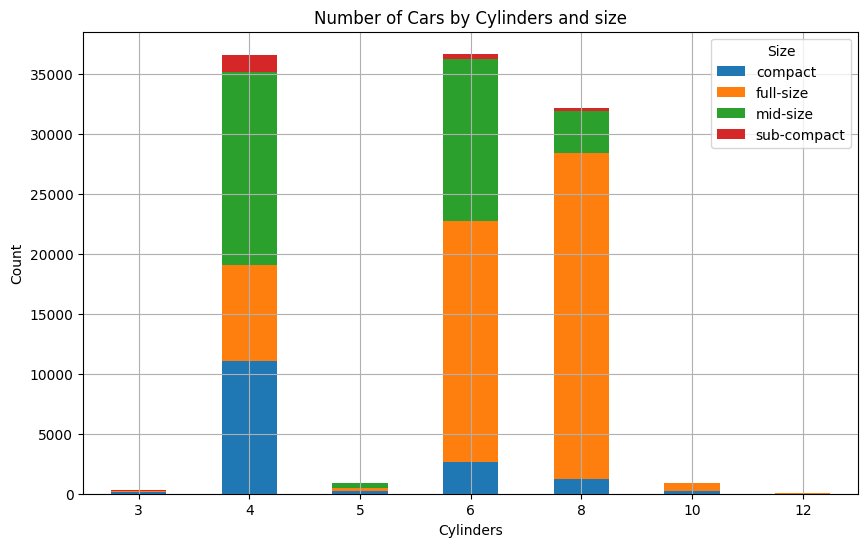

In [433]:
c_filled = df_clean[df_clean["cylinders"].notna()]
c_filled["cylinders"] = c_filled["cylinders"].astype(int)
ct = pd.crosstab(c_filled["cylinders"], c_filled["size"])
# Bar plot
ct.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.xlabel("Cylinders")
plt.ylabel("Count")
plt.title("Number of Cars by Cylinders and size")
plt.xticks(rotation=0)
plt.legend(title="Size")
plt.grid(True)
plt.show()

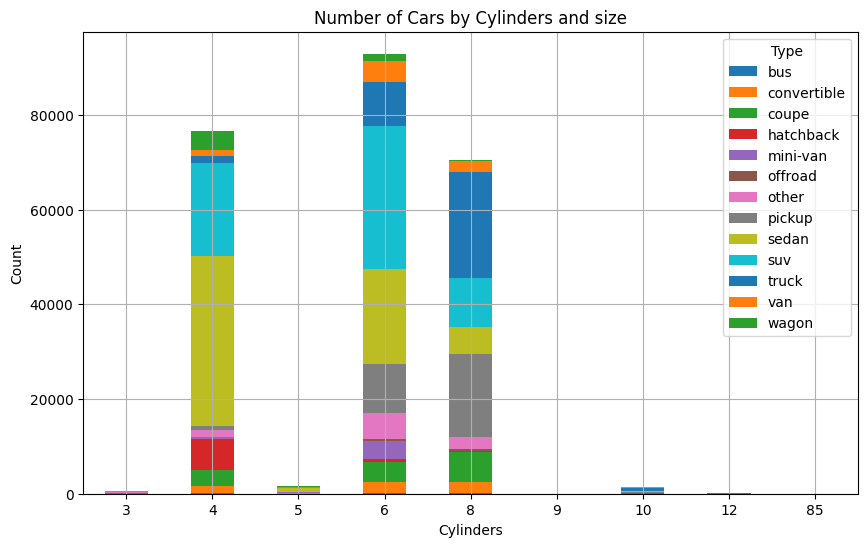

In [434]:
ct = pd.crosstab(c_filled["cylinders"], c_filled["type"])
# Bar plot
ct.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.xlabel("Cylinders")
plt.ylabel("Count")
plt.title("Number of Cars by Cylinders and size")
plt.xticks(rotation=0)
plt.legend(title="Type")
plt.grid(True)
plt.show()

<font color="MidnightBlue">Here are two plots that show how often we see each number of cylinders in cars of a particular size and type. The second graph seems to be more usefull to me as it shows larger difference between distribution of number of cylindres. We can see that sedans most of the times in our dataset have 4 cylinders, SUVs 6, buses 8, pickups 8 etc, we can replace the missing cylinder value with the most common cylinders count for a type
 </font>

In [435]:
most_common_cylinders = (
    c_filled.groupby("type")["cylinders"]
    .agg(lambda x: x.value_counts().idxmax())
)
most_common_cylinders_s = (
    c_filled.groupby("size")["cylinders"]
    .agg(lambda x: x.value_counts().idxmax())
)
print(f"{df_clean["cylinders"].isna().sum() / df_clean.shape[0] * 100}% before replacing")
df_clean["cylinders"] = df_clean["cylinders"].fillna(df_clean["type"].map(most_common_cylinders))
df_clean["cylinders"]  = df_clean["cylinders"].fillna(df_clean["size"].map(most_common_cylinders_s))
print(f"{df_clean["cylinders"].isna().sum() / df_clean.shape[0] * 100}% after replacing")

41.79939063615606% before replacing
1.776957752187324% after replacing


<font color="MidnightBlue">We have significantly reduced the number of missing data after filling them with statistical inferences. Now I can move to condition column which has the significant amount of NaNs.   </font>

In [436]:
bins = [0, 25000, 50000, 75000, 100000, 150000, 200000, np.inf]
labels = ["0-25k", "25-50k", "50-75k", "75-100k",
          "100-150k", "150-200k", "200k+"]

year_bins = [1900.0, 1910.00, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, np.inf ]
year_labels = [
    "1900-09",
    "1910-19",
    "1920-29",
    "1930-39",
    "1940-49",
    "1950-59",
    "1960-69",
    "1970-79",
    "1980-89",
    "1990-99",
    "2000-09",
    "2010-19",
    "2020+"
]


df_clean["odo_bin"] = pd.cut(
    df_clean["odometer"],
    bins=bins,
    labels=labels
)

df_clean["year_bin"] = pd.cut(
    df_clean["year"],
    bins=year_bins,
    labels=year_labels
)
df_clean[df_clean["condition"].isna()][["year_bin", "odo_bin", "title_status"]]
df_clean[df_clean["condition"].notna()][["year_bin", "odo_bin", "title_status", "condition"]]
most_common_conditions = (
    df_clean
    .groupby(["year_bin", "odo_bin", "title_status"])["condition"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

lookup = most_common_conditions.rename("new_condition").reset_index()

df_clean = df_clean.merge(
    lookup,
    on=["year_bin", "odo_bin", "title_status"],
    how="left"
)

In [437]:
df_clean[["condition", "new_condition", "year_bin", "odo_bin", "title_status"]]
#looking up the resulting column, looks good.

,condition,new_condition,year_bin,odo_bin,title_status
0,good,good,2010-19,50-75k,clean
1,good,excellent,2000-09,50-75k,clean
2,good,good,2010-19,0-25k,clean
3,good,good,2010-19,25-50k,clean
4,excellent,excellent,2010-19,100-150k,clean
...,...,...,...,...,...
424372,good,good,2010-19,25-50k,clean
424373,good,good,2010-19,0-25k,clean
424374,good,good,2010-19,0-25k,clean
424375,good,good,2010-19,25-50k,clean


In [438]:
#now we can replace missing values from the new column
print(f"{df_clean["condition"].isna().sum() / df_clean.shape[0] * 100}% missing condition befre replacing")
df_clean["condition"] = df_clean["condition"].fillna(df_clean["new_condition"])
df_clean.drop(columns="new_condition", inplace=True)
print(f"{df_clean["condition"].isna().sum() / df_clean.shape[0] * 100}% missing condition after replacing")

40.61600887889777% missing condition befre replacing
1.2778732117904599% missing condition after replacing


<font color="MidnightBlue"> Here we can see the significant drop in the number of missing values from 41% to 1% It's time to plot the percantage of missing values accross the entire dataset again.</font>

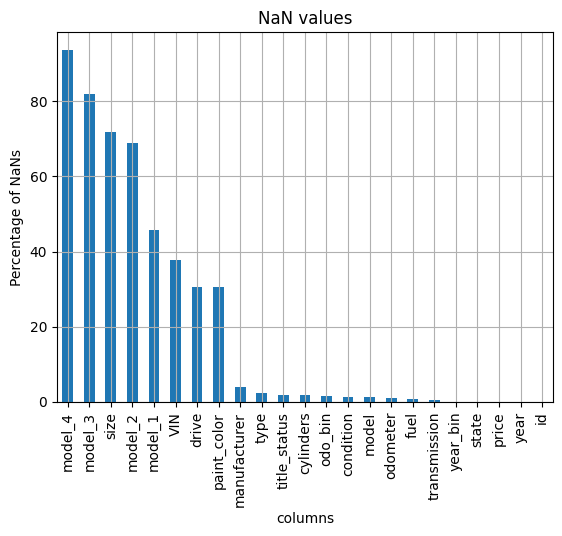

In [439]:
nan_counts = df_clean.isna().sum().sort_values(ascending=False)
nan_counts = (nan_counts / df_clean.shape[0]) * 100
nan_counts.plot(kind='bar')
plt.title("NaN values")
plt.ylabel("Percentage of NaNs")
plt.xlabel("columns")
plt.grid(True)
plt.show()

<font color="MidnightBlue"> We will get rid of the engineered columns model_i and VIN since VIN is unnique for each car, I cannot really infer the paint color from the information I have, and I can work on the drive column. </font>

In [440]:
most_common_dr = (
    df_clean
    .groupby(["type", "manufacturer"])["drive"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
lookup = most_common_dr.rename("new_dr").reset_index()

df_clean = df_clean.merge(lookup, on=["type", "manufacturer"], how="left")
print(f"{df_clean["drive"].isna().sum() / df_clean.shape[0] * 100}% of missing drive values before filling up")
df_clean["drive"] = df_clean["drive"].fillna(df_clean["new_dr"])
df_clean.drop(columns="new_dr", inplace=True)
print(f"{df_clean["drive"].isna().sum() / df_clean.shape[0] * 100}% of missing drive values after filling up")

30.618058942873905% of missing drive values before filling up
2.913918520560728% of missing drive values after filling up


<font color="MidnightBlue">The last column to work on is size. Size can probably be infered from the type and the manufacturer of a car. I am not using model because model column is not consistent and messy</font>

In [441]:
most_common_size= (
    df_clean
    .groupby(["type", "manufacturer"])["size"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
lookup = most_common_size.rename("new_size").reset_index()
df_clean = df_clean.merge(lookup, on=["manufacturer" , "type"], how="left")
df_clean[["new_size", "size", "manufacturer", "type"]]
print(f"{df_clean["size"].isna().sum() / df_clean.shape[0] * 100}% of missing size values before filling up")
df_clean["size"] = df_clean["size"].fillna(df_clean["new_size"])
df_clean.drop(columns="new_size", inplace=True)
print(f"{df_clean["size"].isna().sum() / df_clean.shape[0] * 100}% of missing size values after filling up")

71.73244544355609% of missing size values before filling up
4.561038887592871% of missing size values after filling up


<font color="MidnightBlue"> here we again significantly reduced the number of missing values by making a statistical inference. Now I will remove the engineered colunms, and VIN, paint color, model  </font>

In [442]:
df_clean = df_clean.drop(columns=["id", "paint_color", "VIN", "model", "model_1", "model_2", "model_3", "model_4", "odo_bin", "year_bin"])


In [443]:
df_clean.isna().sum() / df_clean.shape[0] * 100

price           0.000000
year            0.000000
manufacturer    3.820424
condition       1.277873
cylinders       1.776958
fuel            0.646124
odometer        1.020084
title_status    1.843644
transmission    0.586271
drive           2.913919
size            4.561039
type            2.472330
state           0.000000
dtype: float64

In [444]:
df_clean.dropna(inplace=True)
print(f"The original number of entries: {len(df)}, number of entries after clean up {len(df_clean)}. ")
print(f"{(len(df) - len(df_clean)) / len(df) * 100:.2f}% has been removed")

The original number of entries: 426880, number of entries after clean up 384574. 
9.91% has been removed


<font color="MidnoghtBlue">Now when we got rid of missing values, I wan to check the quality of existing values. </font>

In [445]:
df_clean["price"].sort_values()

212639             0
176992             0
176993             0
176994             0
177011             0
             ...    
183331    1410065407
256114    3024942282
90809     3024942282
316685    3736928711
354742    3736928711
Name: price, Length: 384574, dtype: int64

<font color="MidnightBlue"> We see strange numbers among prices, zeros and billions. Let's see how many of them are there before deciding what to do about the suspicious rpices
 </font>

In [446]:
zero_prices = (df_clean["price"] == 0).sum()

print("Number of zero prices:", zero_prices)
print(f"Percentage:, {zero_prices / len(df_clean) * 100}")

Number of zero prices: 27919
Percentage:, 7.259721145995308


In [447]:
thresholds = [0, 100000, 500000, 1000000]

for t in thresholds:
    count = (df_clean["price"] > t).sum()
    print(f"Prices above {t}: {count} ({count/len(df_clean)*100:.3f}%)")

Prices above 0: 356655 (92.740%)
Prices above 100000: 400 (0.104%)
Prices above 500000: 39 (0.010%)
Prices above 1000000: 30 (0.008%)


In [448]:
df[df["price"] > 1000000].head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
280,7315849335,birmingham,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
1838,7315961634,dothan,99999999,1993.0,ford,ranger,NaN,NaN,gas,99999.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,al
26075,7314964461,fresno / madera,1111111,2014.0,chevrolet,NaN,NaN,NaN,other,11.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,ca
29386,7305265540,humboldt county,1111111111,1999.0,ford,f350 super duty lariat,good,8 cylinders,diesel,149000.0,clean,automatic,NaN,rwd,full-size,pickup,white,ca
37409,7314053169,modesto,1111111111,2020.0,jeep,NaN,NaN,NaN,gas,1000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,ca


<font color="MidnightBlue"> Looks like the prices above 1 million are just random numbers, since our task is to find which featuires drive the price, I think it is better to delete these entries rather than filling them up with the means or medians. And the percantage of them is not high. Same is happening with the prices larger than 500000.   </font>

In [449]:
df_clean = df_clean[df_clean["price"] <= 500000]
df_clean[df_clean["price"] <= 400000]["price"].sort_values()
#the maximum price here is  349999. I want to check this row to see how realistic it is
df_clean[df_clean["price"] >= 300000]

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
43876,347999,2020.0,ferrari,excellent,8,gas,3000.0,clean,automatic,rwd,mid-size,coupe,ca
44903,349999,2020.0,ferrari,excellent,8,gas,2800.0,clean,automatic,rwd,mid-size,coupe,ca
87837,304995,2021.0,porsche,new,6.0,gas,22.0,clean,automatic,rwd,compact,convertible,dc
89513,304995,2021.0,porsche,new,6.0,gas,22.0,clean,automatic,rwd,compact,convertible,dc
132488,425000,1993.0,jeep,excellent,6.0,gas,380.0,clean,automatic,4wd,full-size,convertible,id
397347,304995,2021.0,porsche,new,6.0,gas,22.0,clean,automatic,rwd,compact,convertible,va


<font color="MidnightBlue">Data above 300000 looks more realistic, the elite cars are listed with these prices
7% of data have price == 0. I'll remove them.
</font>

In [450]:
count = df_clean[df_clean["price"] == 0]["price"].count()
print(f"Prices equal to 0: {count} ({count/len(df_clean)*100:.3f}%)")
df_clean = df_clean[df_clean["price"] > 100]


Prices equal to 0: 27919 (7.260%)


In [451]:
df_clean[df_clean["price"] > 5]["price"].sort_values()
#I see some strange prices like 6. I'm gonna investigate what it is
df_clean[(df_clean["price"] > 100) & (df_clean["price"] <= 1000)]
#This segment of prices looks good.


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
338,199,2017.0,dodge,good,4.0,gas,21737.0,clean,automatic,rwd,full-size,sedan,al
729,199,2017.0,dodge,good,4.0,gas,21737.0,clean,automatic,rwd,full-size,sedan,al
906,199,2017.0,dodge,good,4.0,gas,21737.0,clean,automatic,rwd,full-size,sedan,al
1022,300,1999.0,saturn,fair,4,gas,265000.0,clean,automatic,fwd,mid-size,sedan,al
1124,199,2017.0,dodge,good,4.0,gas,21737.0,clean,automatic,rwd,full-size,sedan,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423841,600,2002.0,saturn,good,4,gas,150000.0,clean,automatic,fwd,compact,sedan,wy
423856,500,2000.0,dodge,good,6,gas,187000.0,clean,automatic,fwd,full-size,van,wy
424163,950,1995.0,ford,good,8,gas,209452.0,clean,automatic,4wd,full-size,truck,wy
424243,800,2000.0,cadillac,excellent,8,gas,100000.0,clean,automatic,rwd,full-size,coupe,wy


<font color="MidnightBlue">The mdeian price for the used cars is 15500, everything below 100 far away from the  median and looks unrealisitc in the table, they're all recorded as excellent cars in new condition with a two digit odometer number, so it looks like fake data. I am going to update the cell above to increase the threshhold from 0 to 100ю

Now let's check odometer values.
</font>

In [452]:
df_clean[df_clean["odometer"] <= 0]["odometer"].sort_values()

# there are no odometers with negative values
count = (df_clean["odometer"] <= 0).sum()
print(f"Odometer equal to 0: {count} ({count/len(df_clean)*100:.3f}%)")
df_clean  = df_clean[df_clean["odometer"] > 0]


Odometer equal to 0: 349 (0.099%)


In [453]:
df_clean["odometer"].quantile([0.95, 0.99, 0.995, 0.999, 1.0])

0.950      203658.0
0.990      267030.8
0.995      300000.0
0.999      999999.0
1.000    10000000.0
Name: odometer, dtype: float64

<font color="MidnightBlue"> Here we can see that 99.5%.% have less or euqal  300000.0 miles,which is still a realistic number, 0.5% more than that. We can explore 0.5% of this data and delete all of it or partially
 </font>

In [454]:
df_clean[df_clean["odometer"] > 500000]
#some of these numbers look pretty realisitc, I will increase the threshhold from 300_000 to 500_000
df_clean[df_clean["odometer"] > 500000]["odometer"].sort_values()
#the smallest for the threshhold of larger than 500_000 is 500100.0 the largest 10000000.0


242247      500100.0
241747      500100.0
239764      500100.0
288065      500900.0
389304      503000.0
             ...    
43770     10000000.0
80633     10000000.0
151341    10000000.0
290549    10000000.0
259236    10000000.0
Name: odometer, Length: 627, dtype: float64

<font color="MidnightBlue">after some more data exploration, I came to conclusion that it is best to remove data where odometer is more than 500000. Even though some values in the range can be real but a big amount of data looks suspicios, and it is not a significant % of data to remove </font>

In [455]:
df_clean = df_clean[df_clean["odometer"] < 500000]

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [456]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 352626 entries, 0 to 424376
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         352626 non-null  int64  
 1   year          352626 non-null  float64
 2   manufacturer  352626 non-null  str    
 3   condition     352626 non-null  str    
 4   cylinders     352626 non-null  object 
 5   fuel          352626 non-null  str    
 6   odometer      352626 non-null  float64
 7   title_status  352626 non-null  str    
 8   transmission  352626 non-null  str    
 9   drive         352626 non-null  str    
 10  size          352626 non-null  str    
 11  type          352626 non-null  str    
 12  state         352626 non-null  str    
dtypes: float64(2), int64(1), object(1), str(9)
memory usage: 37.7+ MB


<font color= "MidnightBlue">OK, we see that cylinders column is not an integer, we have to convert into int</font>

In [457]:
df_clean["cylinders"] = df_clean["cylinders"].astype(int)
df_clean.info()

<class 'pandas.DataFrame'>
Index: 352626 entries, 0 to 424376
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         352626 non-null  int64  
 1   year          352626 non-null  float64
 2   manufacturer  352626 non-null  str    
 3   condition     352626 non-null  str    
 4   cylinders     352626 non-null  int64  
 5   fuel          352626 non-null  str    
 6   odometer      352626 non-null  float64
 7   title_status  352626 non-null  str    
 8   transmission  352626 non-null  str    
 9   drive         352626 non-null  str    
 10  size          352626 non-null  str    
 11  type          352626 non-null  str    
 12  state         352626 non-null  str    
dtypes: float64(2), int64(2), str(9)
memory usage: 37.7 MB


In [458]:
df_clean["manufacturer"].nunique()
df_clean["state"].nunique()

51

In [459]:
df_clean["condition"].value_counts()

condition
good         176295
excellent    149480
like new      18580
fair           5916
new            1844
salvage         511
Name: count, dtype: int64

<font color="MidnightBlue">Now I will split the data reserving  30%  for testing.</font>

In [460]:
X = df_clean.drop(columns="price")
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<font color="MidnightBlue">Here are 41 types of manufacturers and 51 state, I will run one-hot encoder over this column. It will drammatically increase the number of features but I think it is much better for the result than deleting the column, we can run PCA if needed later. All categorical features will go through the one-hot encoder. And condition will be ordinal. </font>

In [461]:
condition_order = [
    ["salvage", "fair", "good", "excellent", "like new", "new"]
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore"),
            ["manufacturer", "fuel", "title_status", "transmission", "drive", "type", "state"]
        ),
        (
            "ordinal",
            OrdinalEncoder(categories=condition_order),
            ["condition"]
        ),
        (
            "scaler",
            StandardScaler(),
            ["cylinders", "odometer", "year"]
        )
    ]
)


In [462]:
preprocesses = preprocessor.fit_transform(X_train)
selector = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select=5,
    direction="forward",
    scoring="neg_mean_squared_error",
    cv=5
)

selector.fit(preprocesses, y_train)




,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'neg_mean_squared_error'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,126
n_features_to_select_ n_features_to_select_: intThe number of features that were selected.,int64,np.int64(5)
"support_ support_: ndarray of shape (n_features,), dtype=boolThe mask of selected features.","ndarray[bool](126,)","[False,False,False,..., True, True, True]"


<font color="MidnightBlue">I need to decide which model to use, I will start with a simple Linear regression from sklearn </font>

In [463]:
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("linreg", LinearRegression()),
    ]
)
pipe.fit(X_train, y_train)
pred_train = pipe.predict(X_train)
train_mse = mean_squared_error(y_train, pred_train)
train_mae = mean_absolute_error(y_train, pred_train)
print(f"Train MSE: {train_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
pred_test = pipe.predict(X_test)
test_mse = mean_squared_error(y_test, pred_test)
test_mae = mean_absolute_error(y_test, pred_test)
print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f}")


Train MSE: 86041970.10
Train MAE: 5984.15
Test MSE: 88050201.19
Test MAE: 6024.60


<font color="MidnightBlue"> The model is too biased based on the erorr metrics. Since I have too many feattires already after using hot-encoding, I don't thisnk adding more features is a good choice. Instead, I want to add a regularization. I will use the Ridge model which will punish the featires that create a bigger gap between the actual value and predicted. I start with [0.1, 1, 10, 100] alfas and will see where it will take me. I will select the best alfa based on the test error.

I will not save the block in the process of tuning, instead, I will just record my findings as a text here.

alfas = [0.1, 1, 10, 100]
gave me the following results:
<font color="Purple">
error: 17464735914055.178
alfa: 100
</font>

Which means, I have to move towards more regularisation and increase my alfa. I qill try this set now [100, 150, 200, 250]

The next iteration:
<font color="Purple">
MSE 17,448,610,195,718.18
best alfa  250
</font>

the error is reducing, I will increase alfa  more than that to [250, 350, 450, 550]
<font color="Purple">
 MSE 17,431,599,676,836.49
best alfa  550
</font>
It again selected the biggest alfa, maybe I should increase the number of steps between the values, I want the  model to fall into the middle of my range. [550, 1000, 1550, 2550]

It again selected the biggest one, now I start to doubt I am doing the right thing.
<font color="Purple">
MSE 17,403,345,757,363.33
best alfa  2550
</font>
OK, I will try to increase it to alfas = [2550, 5550, 8550, 11550], and then I try to decrease the number of features and compare the results.

This combination alfas = [60080,600090,600098] made the model fall into the middle
<font color="Purple">
MSE 17,367,840,306,274.84
best alfa  600090
</font>
However, the error has not been reduced, I am trying other approaches 1)sequential feaure selction, 2)PCA. 3)polynimial

### After better data prep the simple LinearRegression:

Train MSE: 86041970.10

Train MAE: 5984.15

Test MSE: 88050201.19

Test MAE: 6024.60
</font>

<font color="MidnightBlue">I am rerunning the search for the best param for the other models after fixing my price and odometer issues </font>

In [476]:
alfas = [0.00001, 0.0001, 0.001, 0.01]
min_test_err = np.inf
best_mae = 0
best_alfa = 0
for a in alfas:
    pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("ridge", Ridge(alpha=a)),
    ]
    )
    pipe.fit(X_train, y_train)
    pred_test = pipe.predict(X_test)
    test_mse = mean_squared_error(y_test, pred_test)
    test_mae = mean_absolute_error(y_test, pred_test)

    if test_mse < min_test_err:
        min_test_err = test_mse
        best_alfa = a
        best_mae = test_mae

print(f" MSE {min_test_err:,.2f}")
print(f" MAE {min_test_err:,.2f}")
print("best alfa ", best_alfa)


 MSE 88,048,138.99
 MAE 88,048,138.99
best alfa  0.001


<font color="MidnightBlue">
## After better data clean up Ridge regression

MSE 88,048,138.99

MAE 88,048,138.99

best alfa  0.001
</font>

In [477]:
#I need to see how many features I end up with after transformers
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
print(X_train_transformed.shape)

(246838, 126)


<font color="MidnightBlue">After experimenting with different parametrs with SequentialFeatureSelector and running it different ways, I came to conclusion, it works too slow, and I will not run my experiments with this tool. Instead, I will try a PCA model and Lasso. </font>

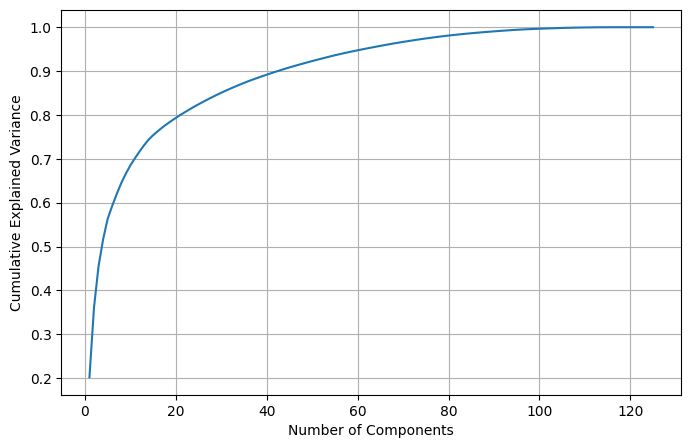

In [478]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_transformed)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()

plt.show()

<font color="MidnightBlue"> I ran my pipeline with PCA and Ridge. First I tryied to choose the number of components that save at least 80% of information, but in the process of tuning the n-components and and alphas for Ridge, my model selected these parameters:
<font color="Purple">

MSE 17,368,681,521,150.71

MAE 79,464.95

best comp 5

best alfa  0.001
</font>

After some more fine-tuning:
<font color="Purple">

MSE 17,367,681,966,923.84

MAE 74,899.53

best comp 5

best alfa  600000

## Rerunning the experiment after better data clean up
</font>
</font>

In [484]:
alphas = [1e-12, 1e-13, 1e-14, 1e-15, 1e-16, 1e-17]

components = [2,3,4,5, 10, 20, 30, 50, 100]

min_test_err = np.inf
best_mae = 0
best_alfa = 0
best_comp = 0
for c in components:
    for a in alphas:
        pipe = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("pca", PCA(n_components=c)),
            ("ridge", Ridge(alpha=a)),
        ]
        )
        pipe.fit(X_train, y_train)
        pred_test = pipe.predict(X_test)
        test_mse = mean_squared_error(y_test, pred_test)
        test_mae = mean_absolute_error(y_test, pred_test)

        if test_mse < min_test_err:
            min_test_err = test_mse
            best_alfa = a
            best_mae = test_mae
            best_comp = c

print(f" MSE {min_test_err:,.2f}")
print(f" MAE {best_mae:,.2f}")
print(f" best comp {best_comp}")
print("best alfa ", best_alfa)

 MSE 90,916,043.18
 MAE 6,072.42
 best comp 100
best alfa  1e-13


<font color="MidnightBlue">LASSO Experiments

LASSO with PCA:

<font color="Purple">

MSE 17,368,681,521,048.32

MAE 79,464.95

best comp 5

best alfa  0.001
</font>

I tired LASSO without PCA, results headed to the worse direction, so insted I'll try to increase lasso alpha for the PCAmodel

Experimenting with larger alphas, I came to these results:
<font color="Purple">

MSE 17,367,931,980,458.26

MAE 74,913.87

best alfa  20700

best comp 3
 </font>

</font>

In [487]:
alphas = [1e-8, 1e-12, 1e-13, 1e-14, 1e-15, 1e-16, 1e-17]
components = [2,3,4,5, 10, 20, 30, 50, 100]

min_test_err = np.inf
best_mae = 0
best_alfa = 0
best_comp = 0
for c in components:
    for a in alphas:
        pipe = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("pca", PCA(n_components=c)),
            ("lasso", Lasso(alpha=a)),
        ]
        )
        pipe.fit(X_train, y_train)
        pred_test = pipe.predict(X_test)
        test_mse = mean_squared_error(y_test, pred_test)
        test_mae = mean_absolute_error(y_test, pred_test)

        if test_mse < min_test_err:
            min_test_err = test_mse
            best_alfa = a
            best_mae = test_mae
            best_comp = c


print(f" MSE {min_test_err:,.2f}")
print(f" MAE {best_mae:,.2f}")
print("best alfa ", best_alfa)
print(f" best comp {best_comp}")

/Users/vilya/Desktop/BerkeleyML/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.195154e+11, tolerance: 5.360e+09
  model = cd_fast.enet_coordinate_descent(
/Users/vilya/Desktop/BerkeleyML/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.801832e+12, tolerance: 5.360e+09
  model = cd_fast.enet_coordinate_descent(
/Users/vilya/Desktop/BerkeleyML/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the fe

 MSE 90,916,043.18
 MAE 6,072.42
best alfa  1e-12
 best comp 100


/Users/vilya/Desktop/BerkeleyML/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.091502e+13, tolerance: 5.360e+09
  model = cd_fast.enet_coordinate_descent(


<font color="MidnightBlue">
## LASSO after dbetter data clean up

MSE 90,916,043.18

MAE 6,072.42

best alfa  1e-12

best comp 100</font>

<font color="MidnightBlue">Now I want to experiment with polynimial features.

MSE 17,788,606,988,432.52

MAE 259,997.98

degree 3

best alfa  20700

It works worse, I will not experiment with larger degrees, since it takes too long.
</font>

In [469]:
# degree = [3]
# min_test_err = np.inf
# best_mae = 0
# best_alfa = 0
# best_degree = 0
# for d in degree:
#     for a in alphas:
#         pipe = Pipeline(
#         [
#             ("preprocessor", preprocessor),
#             ("poly", PolynomialFeatures(degree=d)),
#             ("ridge", Ridge(alpha=a)),
#         ]
#         )
#         pipe.fit(X_train, y_train)
#         pred_test = pipe.predict(X_test)
#         test_mse = mean_squared_error(y_test, pred_test)
#         test_mae = mean_absolute_error(y_test, pred_test)
#
#         if test_mse < min_test_err:
#             min_test_err = test_mse
#             best_alfa = a
#             best_mae = test_mae
#             best_degree = d
#
# print(f" MSE {min_test_err:,.2f}")
# print(f" MAE {best_mae:,.2f}")
# print(f" best degree {best_degree}")
# print("best alfa ", best_alfa)

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

<font color="MidnightBlue">
After all the experiments, I am chosing the Lasso model with these parameters:
best alfa  20700
best comp 3

MSE 17,367,931,980,458.26
MAE 74,913.87

</font>

In [470]:
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("pca", PCA(n_components=3)),
        ("lasso", Lasso(alpha=20700)),
    ]
)
pipe.fit(X_train, y_train)
train_mse = mean_squared_error(y_train, pipe.predict(X_train))
train_mae = mean_absolute_error(y_train, pipe.predict(X_train))

test_mse = mean_squared_error(y_test, pipe.predict(X_test))
test_mae = mean_absolute_error(y_test, pipe.predict(X_test))
print(f" Train MSE {train_mse:,.2f}")
print(f" Train MAE {train_mae:,.2f}")
print(f" Test MSE {test_mse:,.2f}")
print(f" Test MAE {test_mae:,.2f}")


 Train MSE 217,143,147.72
 Train MAE 11,471.13
 Test MSE 220,840,824.94
 Test MAE 11,516.47


<font color="MidnightBlue">Here we can see that the test error is significantly lower than the train error, I delibertly was chosing the momdel based on the test error to avoid overfitting. </font>

In [471]:
from sklearn.inspection import permutation_importance
important = permutation_importance(pipe, X_test, y_test,
                           n_repeats=30,
                           random_state=0)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": important.importances_mean,
    "std": important.importances_std
})



In [472]:
pipe.score(X_test, y_test)

-1.741697654988883e-07

<font color="MidnightBlue"> The plot for the feature importance looks suspicios and the pipe.score did not give a good number -0.0001043645001772564. So I am coming back to the data prep stage. Perhaps I need to do a better analysis of the data and do more cleaning. </font>

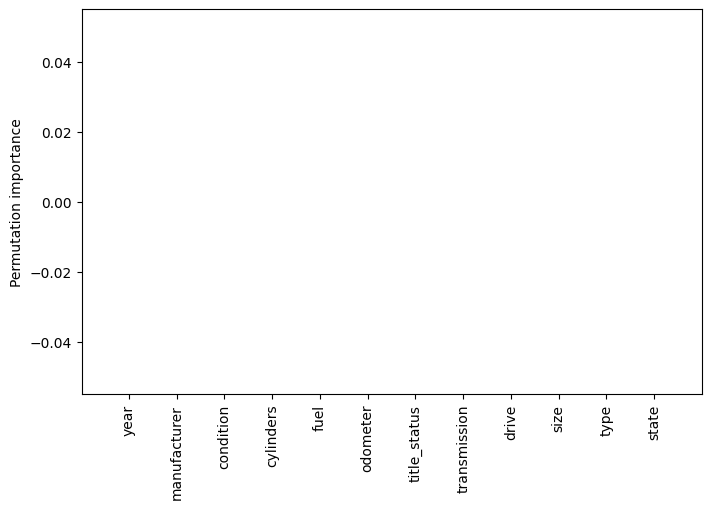

In [473]:
importance_df = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=90)
plt.ylabel("Permutation importance")
plt.show()

In [474]:
importance_df.sort_values("importance", ascending=False)
print(df["price"].describe())

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.